## Prediction of Customer Churn Pbobability

**Version 1.0**
The notebook in fourth entry to competition I started with Basics to start with using Random Fore7r, before I test pipelione and ensemble

**Version 2.0**
Random Forests tend to struggle with this because they average predictions from many trees, which often pushes probabilities away from 0 and 1 toward the center.
This version introduces Random Forest Calibration By applying Platt Scaling (Sigmoid calibration), turns a mathematical output into a reliable financial metric for churn prevention strategies.

**Version 3.0**
Introduced GridSearchCV: It no longer guesses the number of trees; it tests 50, 100, 150, 200, 250 and 300 to find the most accurate estimator for specific data.

**Version 4.0**
Introduced notebook pipeline using Balanced Random Forest (from imblearn) designed to:
- Handle churn imbalance properly
- Increase churn probability sensitivity
- Optimize for ROC-AUC
- Improve recall for churners
- Provide calibrated probabilities
- Use stratified CV
- Automatically tune threshold

In [1]:
# =============================================================================
# 1. Import Libraries
# =============================================================================
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import roc_auc_score, classification_report, brier_score_loss
from sklearn.preprocessing import LabelEncoder
from sklearn.calibration import CalibratedClassifierCV

from imblearn.ensemble import BalancedRandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)
# Set visual style
sns.set(style="whitegrid")


In [2]:
# =============================================================================
# 2. Data Loading 
# =============================================================================
train_df = pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/test.csv")

print("Completed Loading Data ...")
print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

test_ids = test_df["id"].copy()

# Descriptive Statistics
stats = train_df.describe()

print("\nDescriptive Stats:\n", stats)


Completed Loading Data ...
Train shape: (594194, 21)
Test shape : (254655, 20)

Descriptive Stats:
                   id  SeniorCitizen         tenure  MonthlyCharges  \
count  594194.000000  594194.000000  594194.000000   594194.000000   
mean   297096.500000       0.114102      36.577258       65.866223   
std    171529.177262       0.317936      25.061922       31.067444   
min         0.000000       0.000000       1.000000       18.250000   
25%    148548.250000       0.000000      12.000000       29.900000   
50%    297096.500000       0.000000      35.000000       74.100000   
75%    445644.750000       0.000000      62.000000       90.800000   
max    594193.000000       1.000000      72.000000      118.750000   

        TotalCharges  
count  594194.000000  
mean     2494.377057  
std      2353.916710  
min        18.800000  
25%       639.650000  
50%      1433.650000  
75%      4263.800000  
max      8684.800000  


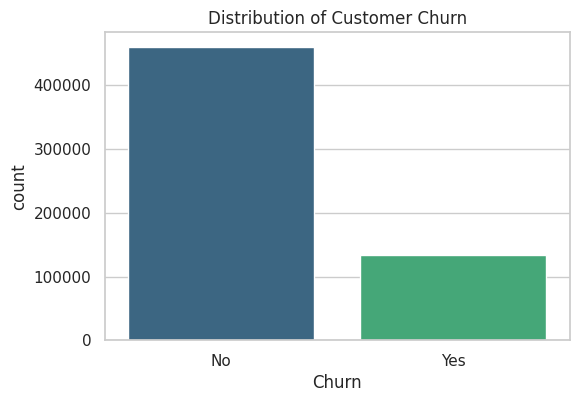

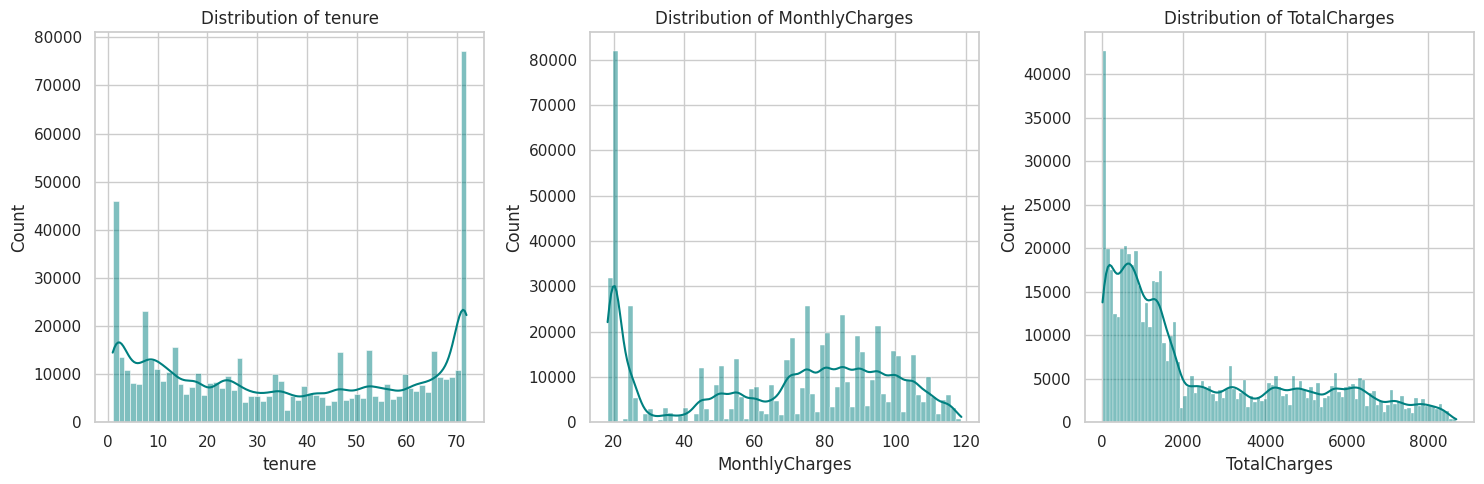

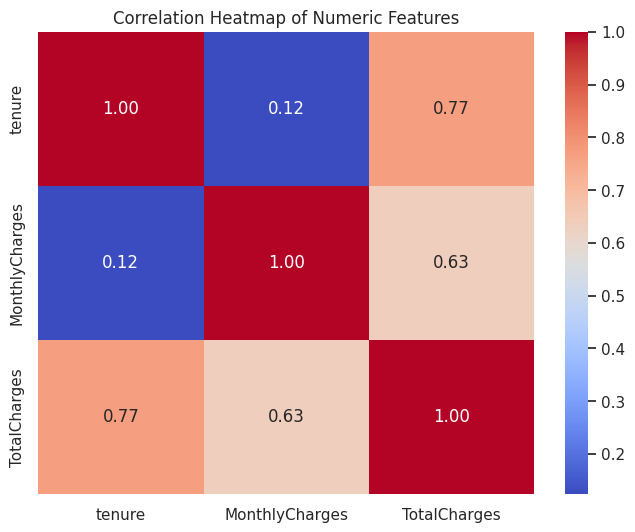

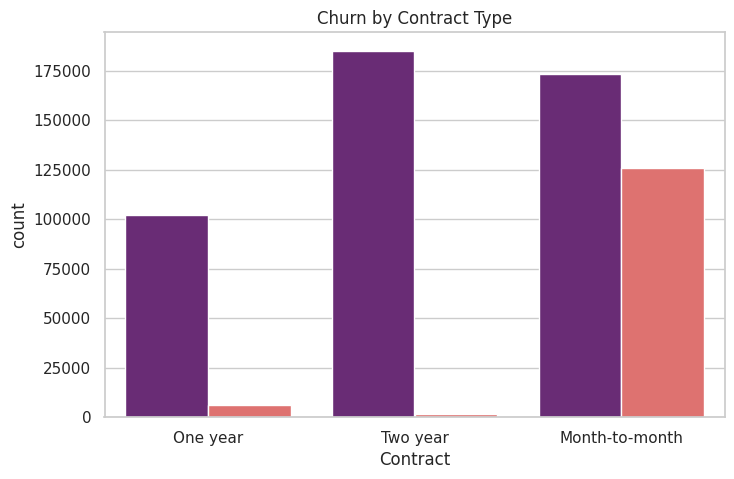

In [3]:
# =============================================================================
# 3. Basic Exploratory Data Analytics
# =============================================================================

# Fix TotalCharges
for df in [train_df, test_df]:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
    df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# Distribution of Target Variable (Churn)
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=train_df, palette='viridis', legend=False)
plt.title('Distribution of Customer Churn')
plt.savefig('churn_distribution.png')

# Numeric Features Distribution
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(15, 5))
for i, col in enumerate(numeric_features, 1):
    plt.subplot(1, 3, i)
    sns.histplot(train_df[col], kde=True, color='teal')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('numeric_distributions.png')

# Correlation Heatmap
plt.figure(figsize=(8, 6))
correlation = train_df[numeric_features].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.savefig('correlation_heatmap.png')

# Churn by Contract Type (Categorical Analysis)
plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', hue='Churn', data=train_df, palette='magma', legend=False)
plt.title('Churn by Contract Type')
plt.savefig('churn_by_contract.png')


In [4]:
# =============================================================================
# 4. Label Encoding for Categorical Columns
# =============================================================================
le_dict = {}

cat_cols = train_df.select_dtypes(include="object").columns.tolist()
cat_cols.remove("Churn")

for col in cat_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col].astype(str))
    test_df[col]  = le.transform(test_df[col].astype(str))
    le_dict[col] = le

# Encode target
train_df["Churn"] = train_df["Churn"].map({"Yes":1, "No":0})

# Feature matrix
X = train_df.drop(["id","Churn"], axis=1)
y = train_df["Churn"]

X_test = test_df.drop(["id"], axis=1)

print("Churn rate:", y.mean())

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)

print("Train churn rate:", y_train.mean())
print("Val churn rate  :", y_val.mean())

Churn rate: 0.225207592133209
Train churn rate: 0.22520852836301292
Val churn rate  : 0.22520384722187162


In [5]:
# =============================================================================
# 5. Hyper Parameter Optimization
# =============================================================================
print("Optimizing n_estimators via Grid Search...")

param_grid = {
    "n_estimators": [100, 150, 200, 250, 300, 350, 450],
    "max_depth": [10, 20, None],
    "min_samples_leaf": [2, 4]
}

brf = BalancedRandomForestClassifier(
    random_state=SEED,
    n_jobs=-1,
    sampling_strategy="auto",
    replacement=False
)

grid = GridSearchCV(
    brf,
    param_grid,
    cv=7,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

results = grid.cv_results_

print("\nDetailed Fold Results (Top 5 Combinations):")
print("-" * 80)
for i in range(len(results['params'])):
    if results['rank_test_score'][i] <= 5: # Limit output to top 5 for readability
        print(f"Params: {results['params'][i]}")
        print(f"  Fold 1 AUC: {results['split0_test_score'][i]:.4f}")
        print(f"  Fold 2 AUC: {results['split1_test_score'][i]:.4f}")
        print(f"  Fold 3 AUC: {results['split2_test_score'][i]:.4f}")
        print(f"  MEAN AUC:   {results['mean_test_score'][i]:.4f} (+/- {results['std_test_score'][i]:.4f})")
        print("-" * 30)

# Final Summary
best_brf = grid.best_estimator_
print("\nBest Parameters:", grid.best_params_)
print("Best CV AUC:", grid.best_score_)


Optimizing n_estimators via Grid Search...
Fitting 7 folds for each of 42 candidates, totalling 294 fits

Detailed Fold Results (Top 5 Combinations):
--------------------------------------------------------------------------------
Params: {'max_depth': 20, 'min_samples_leaf': 4, 'n_estimators': 200}
  Fold 1 AUC: 0.9127
  Fold 2 AUC: 0.9107
  Fold 3 AUC: 0.9117
  MEAN AUC:   0.9125 (+/- 0.0013)
------------------------------
Params: {'max_depth': 20, 'min_samples_leaf': 4, 'n_estimators': 250}
  Fold 1 AUC: 0.9128
  Fold 2 AUC: 0.9107
  Fold 3 AUC: 0.9118
  MEAN AUC:   0.9125 (+/- 0.0013)
------------------------------
Params: {'max_depth': 20, 'min_samples_leaf': 4, 'n_estimators': 300}
  Fold 1 AUC: 0.9128
  Fold 2 AUC: 0.9108
  Fold 3 AUC: 0.9118
  MEAN AUC:   0.9125 (+/- 0.0013)
------------------------------
Params: {'max_depth': 20, 'min_samples_leaf': 4, 'n_estimators': 350}
  Fold 1 AUC: 0.9128
  Fold 2 AUC: 0.9108
  Fold 3 AUC: 0.9118
  MEAN AUC:   0.9125 (+/- 0.0013)
--------


Validation ROC-AUC: 0.9129735481086111
Best Recall: 0.8938086163733513
Optimal Threshold: 0.2

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.78      0.86     92076
           1       0.54      0.89      0.67     26763

    accuracy                           0.80    118839
   macro avg       0.75      0.84      0.77    118839
weighted avg       0.87      0.80      0.82    118839



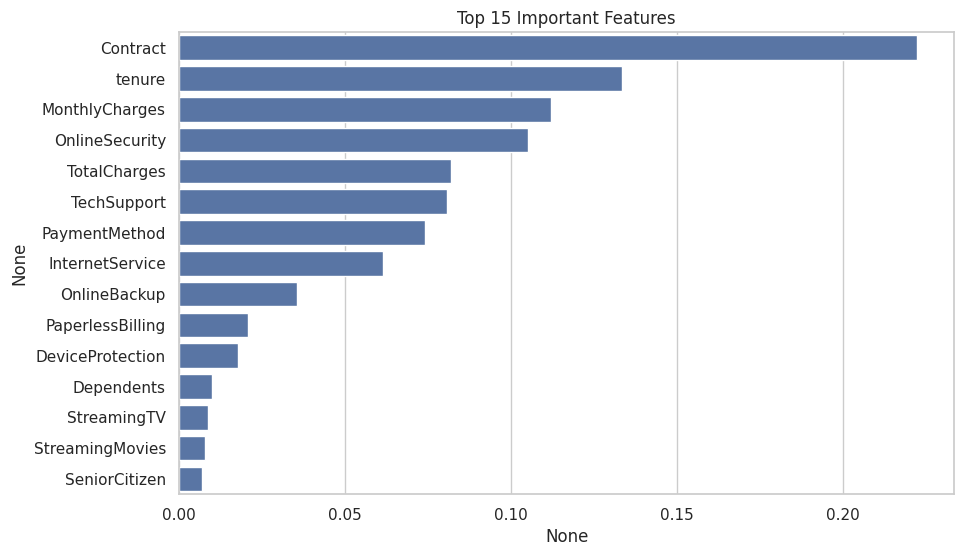

In [6]:
# =============================================================================
# 6. FEATURE IMPORTANCE VISUALIZATION
# =============================================================================

calibrated_brf = CalibratedClassifierCV(
    best_brf,
    method="isotonic",
    cv=5
)

calibrated_brf.fit(X_train, y_train)

val_probs = calibrated_brf.predict_proba(X_val)[:,1]

# Optimize threshold for recall
thresholds = np.arange(0.2, 0.6, 0.02)
best_recall = 0
best_thresh = 0.35

for t in thresholds:
    preds = (val_probs >= t).astype(int)
    recall = classification_report(y_val, preds, output_dict=True)["1"]["recall"]
    if recall > best_recall:
        best_recall = recall
        best_thresh = t

print("\nValidation ROC-AUC:", roc_auc_score(y_val, val_probs))
print("Best Recall:", best_recall)
print("Optimal Threshold:", best_thresh)

val_preds = (val_probs >= best_thresh).astype(int)

print("\nClassification Report:")
print(classification_report(y_val, val_preds))

importances = pd.Series(best_brf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances[:15], y=importances.index[:15])
plt.title("Top 15 Important Features")
plt.show()


In [7]:
# =============================================================================
# 7. Final Predictions
# =============================================================================
test_probs = calibrated_brf.predict_proba(X_test)[:,1]

# Optional: Slight probability boost
test_probs = np.clip(test_probs * 1.10, 0, 1)

TARGET = 'Churn'

# Create output dataframe
submission = pd.DataFrame({
    "id": test_ids,
    "Churn_Probability": np.round(test_probs, 5)
})




In [8]:
# =============================================================================
# 9. Submission
# =============================================================================
submission.to_csv("submission.csv", index=False)

print("\nSubmission Created Successfully.")

submission.head(20)



Submission Created Successfully.


,id,Churn_Probability
0,594194,0.06472
1,594195,0.00099
2,594196,0.14644
3,594197,0.00302
4,594198,0.58083
5,594199,0.22263
6,594200,0.99257
7,594201,0.00496
8,594202,0.02514
9,594203,0.40306
